# Análisis Exploratorio de Datos (EDA) — GP de Abu Dhabi 2021

Este notebook analiza la carrera del Gran Premio de Abu Dhabi 2021 (la famosa definición del título entre **Max Verstappen** y **Lewis Hamilton**) utilizando datos oficiales de telemetría mediante la librería **FastF1**.

## 1. Importación de Librerías y Configuración

In [25]:
#  Librerias 
import fastf1                          # Telemetría y datos oficiales de F1
import pandas as pd                    # Manipulación de datos
import numpy as np                     # Operaciones numéricas
import matplotlib.pyplot as plt        # Visualización
import matplotlib.ticker as ticker     # Formato de ejes
import matplotlib.patches as mpatches  # Permite crear cuadros de color personalizados para la leyenda
import os

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


In [26]:
# 1. Definición de la Paleta de Colores
CARBON      = "#15151E"
F1_RED      = "#E10600"
SILVER      = "#D8DBDF"
SILVER_DIM  = "#7A7D85"
GRID_COLOR  = "#2B2B3A"
ACCENT_GOLD = "#C9A227"
PEREZ_BLUE  = "#5B7FBD"
 
# 2. Configuración Global de Parámetros de Matplotlib
plt.rcParams.update({
    "figure.facecolor": CARBON,
    "axes.facecolor": CARBON,
    "savefig.facecolor": CARBON,
    "text.color": SILVER,
    "axes.labelcolor": SILVER,
    "xtick.color": SILVER_DIM,
    "ytick.color": SILVER_DIM,
    "axes.edgecolor": GRID_COLOR,
    "grid.color": GRID_COLOR,
    "font.size": 12,
})
 
# 3. Mapeo de Colores Oficiales por Compuesto de Neumáticos (Pirelli)
COMPOUND_COLOR = {
    "SOFT": F1_RED,
    "MEDIUM": ACCENT_GOLD,
    "HARD": SILVER,
    "INTERMEDIATE": "#3FA34D",
    "WET": "#2E7DD1",
}
 
# 4. Configuración del Directorio de Salida
OUT_DIR = "../graficas_abu_dhabi_2021"
os.makedirs(OUT_DIR, exist_ok=True)
print("Las graficas se guardaran en:", os.path.abspath(OUT_DIR))
 
# 5. Funciones Auxiliares de Estilizado y Exportación 
def style_ax(ax, title):
    """Ayudante de formato (NO es una grafica en si, solo evita repetir
    7 veces las mismas 5 lineas de estilo)."""
    ax.set_title(title, fontsize=15, fontweight="bold", loc="left",
                 color=SILVER, pad=14)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    for s in ax.spines.values():
        s.set_color(GRID_COLOR)
    ax.tick_params(colors=SILVER_DIM)
 
 
def save(fig, name):
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Guardada: {path}")
    plt.show()
    plt.close(fig)

Las graficas se guardaran en: c:\Users\jomig\Desktop\Formula_1_spk\f1-data-science\graficas_abu_dhabi_2021


## 2. Carga de Datos de la Sesión

Cargamos la **carrera** (`'R'`) del GP de Abu Dhabi 2021 y filtramos las vueltas de Verstappen (`VER`) y Hamilton (`HAM`).

In [27]:
# ---------- Parámetros de la sesión ----------
YEAR        = 2021
GRAND_PRIX  = 'Abu Dhabi'
SESSION     = 'R'            # 'R' = Race, 'Q' = Qualifying, 'FP1/FP2/FP3'

# Cargar sesión (la primera vez descarga ~30 MB, luego usa caché)
session = fastf1.get_session(YEAR, GRAND_PRIX, SESSION)
session.load()

print(f'Sesión cargada: {session.event["EventName"]} {YEAR} — {session.name}')
print(f'Total de vueltas de carrera: {session.total_laps}')

df = session.laps.copy()

df["LapTimeSec"] = df["LapTime"].dt.total_seconds()

Request for URL https://raw.githubusercontent.com/theOehrly/f1schedule/master/schedule_2021.json failed; using cached response
Traceback (most recent call last):
  File "c:\Users\jomig\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connectionpool.py", line 787, in urlopen
    response = self._make_request(
               ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jomig\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "c:\Users\jomig\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jomig\AppData\Local\Programs\Python\Python312\Lib\http\client.py", line 1430, in getresponse
    response.begin()
  File "c:\Users\jomig\AppData\Local\Programs\Python\Python312\Lib\http\client.py",

Sesión cargada: Abu Dhabi Grand Prix 2021 — Race
Total de vueltas de carrera: 58


In [28]:
df.info()

<class 'fastf1.core.Laps'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                1000 non-null   timedelta64[ns]
 1   Driver              1000 non-null   object         
 2   DriverNumber        1000 non-null   object         
 3   LapTime             989 non-null    timedelta64[ns]
 4   LapNumber           1000 non-null   float64        
 5   Stint               1000 non-null   float64        
 6   PitOutTime          29 non-null     timedelta64[ns]
 7   PitInTime           32 non-null     timedelta64[ns]
 8   Sector1Time         979 non-null    timedelta64[ns]
 9   Sector2Time         998 non-null    timedelta64[ns]
 10  Sector3Time         998 non-null    timedelta64[ns]
 11  Sector1SessionTime  978 non-null    timedelta64[ns]
 12  Sector2SessionTime  998 non-null    timedelta64[ns]
 13  Sector3SessionTime  998 non-null    timedelta

## 3. Posiciones y Tiempos

In [29]:
# Filtrar VER y HAM en las últimas vueltas de la 49 a la 58

LAP_START, LAP_END = 49, 58

foc = df[(df["Driver"].isin(["VER", "HAM"])) & (df["LapNumber"].between(LAP_START, LAP_END))
].sort_values(["LapNumber", "Driver"]).copy()

cols = [
    "Driver", "LapNumber", "LapTimeSec", "Compound", "TyreLife",
    "FreshTyre", "Stint", "PitInTime", "PitOutTime", "Position",
]
print("Tabla comparativa VER vs HAM (últimas vueltas)")
print(foc[cols].to_string(index=False))

Tabla comparativa VER vs HAM (últimas vueltas)
Driver  LapNumber  LapTimeSec Compound  TyreLife  FreshTyre  Stint              PitInTime             PitOutTime  Position
   HAM       49.0      86.875     HARD      36.0      False    2.0                    NaT                    NaT       1.0
   VER       49.0      86.657     HARD      13.0       True    3.0                    NaT                    NaT       2.0
   HAM       50.0      86.784     HARD      37.0      False    2.0                    NaT                    NaT       1.0
   VER       50.0      86.748     HARD      14.0       True    3.0                    NaT                    NaT       2.0
   HAM       51.0      86.934     HARD      38.0      False    2.0                    NaT                    NaT       1.0
   VER       51.0      87.048     HARD      15.0       True    3.0                    NaT                    NaT       2.0
   HAM       52.0      86.833     HARD      39.0      False    2.0                    NaT   

In [30]:
# Vueltas con Safety Car
sc_laps = df[df["TrackStatus"].astype(str).str.contains("4")]["LapNumber"].unique()
print(f"\nVueltas con Safety Car activo (TrackStatus contiene '4'): {sorted(sc_laps)}")


Vueltas con Safety Car activo (TrackStatus contiene '4'): [np.float64(51.0), np.float64(52.0), np.float64(53.0), np.float64(54.0), np.float64(55.0), np.float64(56.0), np.float64(57.0)]


In [31]:
# Posiciones anntes del safety car
pre_safety_car_lap = 50
pre_safety_car_positions = df[df['LapNumber'] == pre_safety_car_lap][['Driver', 'Position']].sort_values(by='Position')
print(f"\nPosiciones en la vuelta {int(pre_safety_car_lap)} (antes del Safety Car)")
print(pre_safety_car_positions.to_string(index=False))


Posiciones en la vuelta 50 (antes del Safety Car)
Driver  Position
   HAM       1.0
   VER       2.0
   PER       3.0
   SAI       4.0
   BOT       5.0
   TSU       6.0
   GAS       7.0
   NOR       8.0
   ALO       9.0
   OCO      10.0
   RIC      11.0
   LEC      12.0
   VET      13.0
   STR      14.0
   MSC      15.0
   LAT      16.0


In [32]:
# Posiciones al finalizar la carrera
print("\nPosiciones finales de la carrera:")
final_positions = session.results[['BroadcastName', 'Position']].sort_values(by='Position')
print(final_positions.to_string(index=False))


Posiciones finales de la carrera:
BroadcastName  Position
 M VERSTAPPEN       1.0
   L HAMILTON       2.0
      C SAINZ       3.0
    Y TSUNODA       4.0
      P GASLY       5.0
     V BOTTAS       6.0
     L NORRIS       7.0
     F ALONSO       8.0
       E OCON       9.0
    C LECLERC      10.0
     S VETTEL      11.0
  D RICCIARDO      12.0
     L STROLL      13.0
 M SCHUMACHER      14.0
      S PEREZ      15.0
     N LATIFI      16.0
 A GIOVINAZZI      17.0
    G RUSSELL      18.0
  K RAIKKONEN      19.0
          nan       NaN


In [33]:
# Ultima vuelta Max Vs Hamilton
last_lap = df["LapNumber"].max()

ham_last = df[(df["Driver"] == "HAM") & (df["LapNumber"] == last_lap)]
ver_last = df[(df["Driver"] == "VER") & (df["LapNumber"] == last_lap)]

ham_time = ham_last["LapTimeSec"].values[0]
ver_time = ver_last["LapTimeSec"].values[0]
delta = ham_time - ver_time

print(f"\nVuelta {int(last_lap)}")
print(f"HAM: {ham_time:.3f}s | Compuesto: {ham_last['Compound'].values[0]} "
      f"| Vida neumático: {ham_last['TyreLife'].values[0]:.0f} vueltas")
print(f"VER: {ver_time:.3f}s | Compuesto: {ver_last['Compound'].values[0]} "
      f"| Vida neumático: {ver_last['TyreLife'].values[0]:.0f} vueltas")
print(f"-> M VERSTAPPEN más rápido por {delta:.3f} segundos")


Vuelta 58
HAM: 89.330s | Compuesto: HARD | Vida neumático: 45 vueltas
VER: 86.618s | Compuesto: SOFT | Vida neumático: 8 vueltas
-> M VERSTAPPEN más rápido por 2.712 segundos


Guardada: ../graficas_abu_dhabi_2021\ritmo_ver_ham_abu_dhabi_2021.png


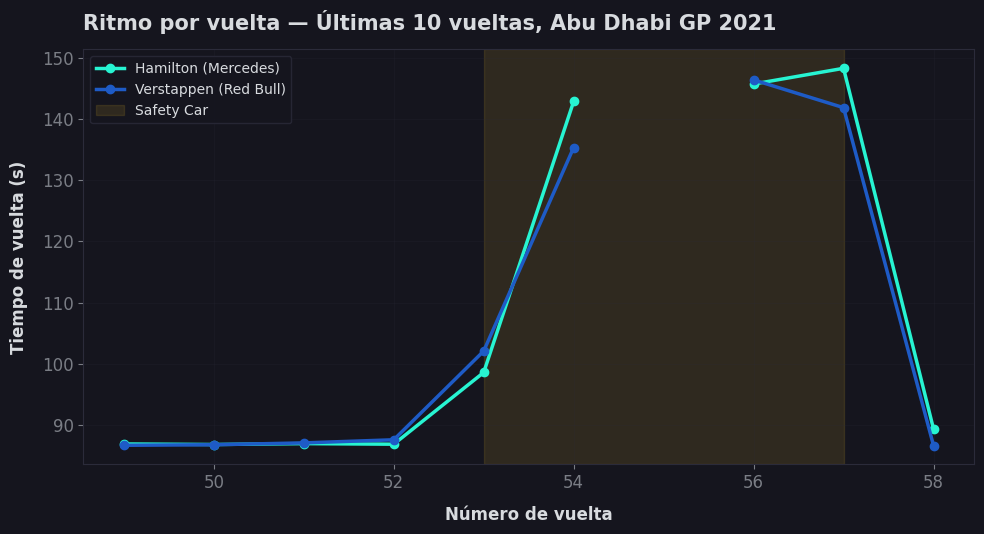

In [34]:
# Grafica comparativa del ritmo ultimas 10 vueltas de Max vs Ham
ham_series = foc[foc["Driver"] == "HAM"].set_index("LapNumber")["LapTimeSec"]
ver_series = foc[foc["Driver"] == "VER"].set_index("LapNumber")["LapTimeSec"]

fig, ax = plt.subplots(figsize=(10, 5.5))

# Gráficas de líneas
ax.plot(ham_series.index, ham_series.values, marker="o", 
        label="Hamilton (Mercedes)", color="#27F4D2", linewidth=2.5, markersize=6)
ax.plot(ver_series.index, ver_series.values, marker="o", 
        label="Verstappen (Red Bull)", color="#1E5BC6", linewidth=2.5, markersize=6)

# Sombreado del Safety Car 
ax.axvspan(53, 57, color=ACCENT_GOLD, alpha=0.15, label="Safety Car")

# Etiquetas de ejes
ax.set_xlabel("Número de vuelta", fontweight="bold", labelpad=10)
ax.set_ylabel("Tiempo de vuelta (s)", fontweight="bold", labelpad=10)

# Aplicar función de estilo 
style_ax(ax, "Ritmo por vuelta — Últimas 10 vueltas, Abu Dhabi GP 2021")

# Leyenda
legend = ax.legend(facecolor=CARBON, edgecolor=GRID_COLOR, fontsize=10)
for text in legend.get_texts():
    text.set_color(SILVER)

# Guardar Grafica
fig.tight_layout()
save(fig, "ritmo_ver_ham_abu_dhabi_2021.png")

## 4. Autos Doblados y Checo Pérez

Guardada: ../graficas_abu_dhabi_2021\defensa_perez_con_pits.png


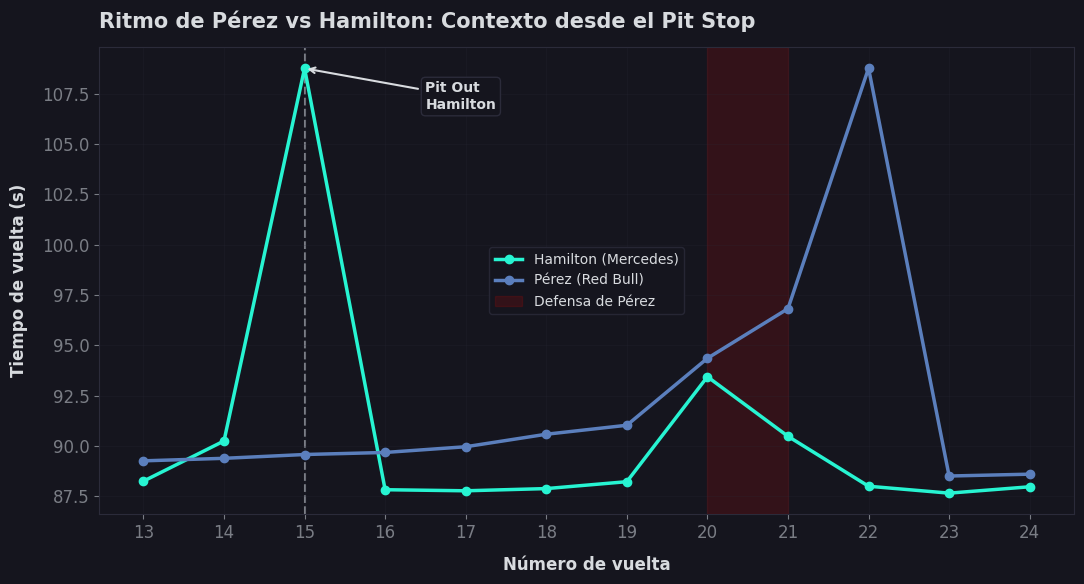

In [35]:
# defensa_perez_con_pits.png
# Ampliamos el rango desde la vuelta 13 para capturar el Pit Stop de Hamilton
LAP_DEF_START, LAP_DEF_END = 13, 24

def_df = df[(df["Driver"].isin(["HAM", "PER"])) & (df["LapNumber"].between(LAP_DEF_START, LAP_DEF_END))].copy()

ham_def = def_df[def_df["Driver"] == "HAM"].set_index("LapNumber")["LapTimeSec"]
per_def = def_df[def_df["Driver"] == "PER"].set_index("LapNumber")["LapTimeSec"]

fig, ax = plt.subplots(figsize=(11, 6))

# Gráficas de líneas
ax.plot(ham_def.index, ham_def.values, marker="o", 
        label="Hamilton (Mercedes)", color="#27F4D2", linewidth=2.5, markersize=6)
ax.plot(per_def.index, per_def.values, marker="o", 
        label="Pérez (Red Bull)", color=PEREZ_BLUE, linewidth=2.5, markersize=6)

# Sombreado del tramo de defensa extrema (Vueltas 20 a 21)
ax.axvspan(20, 21, color=F1_RED, alpha=0.15, label="Defensa de Pérez")

# Hamilton salió de boxes en la vuelta 15 (su 'out-lap' es más lenta)
ax.axvline(x=15, color=SILVER_DIM, linestyle="--", linewidth=1.5, zorder=1)
# Añadimos una flecha y texto explicativo
ax.annotate("Pit Out\nHamilton", 
            xy=(15, ham_def.loc[15]), 
            xytext=(16.5, ham_def.loc[15] - 2),
            arrowprops=dict(facecolor=SILVER, edgecolor=SILVER, arrowstyle="->", lw=1.5), 
            color=SILVER, fontweight="bold", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc=CARBON, ec=GRID_COLOR))

# Etiquetas y formato
ax.set_xlabel("Número de vuelta", fontweight="bold", labelpad=10)
ax.set_ylabel("Tiempo de vuelta (s)", fontweight="bold", labelpad=10)
style_ax(ax, "Ritmo de Pérez vs Hamilton: Contexto desde el Pit Stop")

# Mejorar el formato del eje X para que muestre cada vuelta
ax.set_xticks(range(LAP_DEF_START, LAP_DEF_END + 1))
ax.yaxis.set_major_locator(ticker.MaxNLocator(10))

# Leyenda
legend = ax.legend(facecolor=CARBON, edgecolor=GRID_COLOR, fontsize=10)
for text in legend.get_texts():
    text.set_color(SILVER)

# Guardar Grafica
fig.tight_layout()
save(fig, "defensa_perez_con_pits.png")

In [40]:
# Cálculo de tiempo perdido por Hamilton vs Verstappen
# Vueltas clave de la defensa extrema de Pérez
LAP_DEF_START, LAP_DEF_END = 20, 21

# Filtramos los tiempos de Hamilton y Verstappen en ese tramo
ham_times = df[(df["Driver"] == "HAM") & (df["LapNumber"].between(LAP_DEF_START, LAP_DEF_END))].set_index("LapNumber")["LapTimeSec"]
ver_times = df[(df["Driver"] == "VER") & (df["LapNumber"].between(LAP_DEF_START, LAP_DEF_END))].set_index("LapNumber")["LapTimeSec"]

print("\nImpacto de la defensa de Pérez (Vueltas 20 y 21)")
tiempo_recortado_total = 0

for lap in range(LAP_DEF_START, LAP_DEF_END + 1):
    ham_t = ham_times.loc[lap]
    ver_t = ver_times.loc[lap]
    diff = ham_t - ver_t
    tiempo_recortado_total += diff
    print(f"Vuelta {lap}: HAM = {ham_t:.3f}s | VER = {ver_t:.3f}s -> Verstappen recortó {diff:.3f}s")

print("-" * 55)
print(f"-> TIEMPO TOTAL RECORTADO POR VERSTAPPEN: {tiempo_recortado_total:.3f} segundos")


Impacto de la defensa de Pérez (Vueltas 20 y 21)
Vuelta 20: HAM = 93.443s | VER = 88.387s -> Verstappen recortó 5.056s
Vuelta 21: HAM = 90.485s | VER = 88.569s -> Verstappen recortó 1.916s
-------------------------------------------------------
-> TIEMPO TOTAL RECORTADO POR VERSTAPPEN: 6.972 segundos


Guardada: ../graficas_abu_dhabi_2021\autos_doblados_sc.png


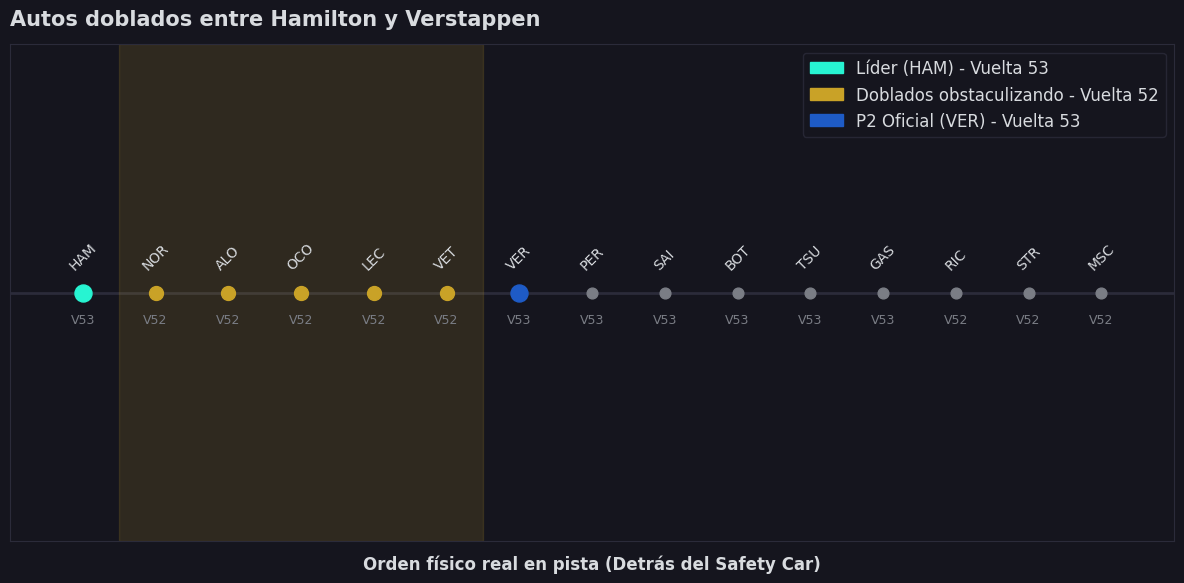

In [38]:
# autos_doblados_sc.png
# Definimos el orden FÍSICO real en la pista detrás del Safety Car (Vuelta 53)
track_order = ['HAM', 'NOR', 'ALO', 'OCO', 'LEC', 'VET', 'VER', 'PER', 'SAI', 'BOT', 'TSU', 'GAS', 'RIC', 'STR', 'MSC']

# Pilotos que estaban obstaculizando entre P1 y P2
lapped_cars_middle = ['NOR', 'ALO', 'OCO', 'LEC', 'VET']

# Todos los pilotos que estaban una vuelta atrás (Vuelta 52) en ese momento
all_lapped_cars = ['NOR', 'ALO', 'OCO', 'LEC', 'VET', 'RIC', 'STR', 'MSC']

fig, ax = plt.subplots(figsize=(12, 6))

# Trazar según el orden físico en lugar de la posición oficial
for i, driver in enumerate(track_order):
    x_pos = i + 1 
    
    if driver == 'HAM':
        color = '#27F4D2'
        size = 150
    elif driver == 'VER':
        color = '#1E5BC6'
        size = 150
    elif driver in lapped_cars_middle:
        color = ACCENT_GOLD
        size = 100
    else:
        color = SILVER_DIM
        size = 60
        
    # Vuelta actual del piloto 
    vuelta_actual = "V52" if driver in all_lapped_cars else "V53"
        
    ax.scatter(x_pos, 1, color=color, s=size, zorder=3)
    
    # Texto ARRIBA: Nombre del piloto
    ax.text(x_pos, 1.05, driver, color=SILVER, fontsize=10, ha='center', va='bottom', rotation=45)
    
    # Texto ABAJO: Vuelta en la que se encuentran
    ax.text(x_pos, 0.95, vuelta_actual, color=SILVER_DIM, fontsize=9, ha='center', va='top')

# Formato decorativo para simular la pista
ax.axhline(1, color=GRID_COLOR, linewidth=2, zorder=1)

# Sombreado sobre los autos físicamente en el medio
ax.axvspan(1.5, 6.5, color=ACCENT_GOLD, alpha=0.15, label="Barrera física (Autos a desdoblarse)")

# Ajustes de ejes
ax.set_xlim(0, len(track_order) + 1)
ax.set_ylim(0.4, 1.6)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlabel("Orden físico real en pista (Detrás del Safety Car)", fontweight="bold", labelpad=10)

style_ax(ax, "Autos doblados entre Hamilton y Verstappen")

# Leyenda personalizada
ham_patch = mpatches.Patch(color='#27F4D2', label='Líder (HAM) - Vuelta 53')
ver_patch = mpatches.Patch(color='#1E5BC6', label='P2 Oficial (VER) - Vuelta 53')
lapped_patch = mpatches.Patch(color=ACCENT_GOLD, label='Doblados obstaculizando - Vuelta 52')
legend = ax.legend(handles=[ham_patch, lapped_patch, ver_patch], facecolor=CARBON, edgecolor=GRID_COLOR, loc='upper right')
for text in legend.get_texts():
    text.set_color(SILVER)

fig.tight_layout()
save(fig, "autos_doblados_sc.png")